# Social Media Sentiment Analysis
### A Data Analytics and Machine Learning Project



This project performs binary sentiment classification on tweets using the Sentiment140 dataset.

The workflow includes:

- Loading and understanding the dataset
- Text preprocessing
- Exploratory Data Analysis (EDA)
- TF-IDF feature extraction
- Logistic Regression model training
- Model comparison
- Saving the trained model for deployment

The final application will be deployed using FastAPI, MongoDB, and a frontend interface.


## Problem Statement

Social media platforms generate millions of user opinions every day.

Automatically identifying whether a tweet expresses positive or negative sentiment can help businesses, researchers, and organizations understand public opinion at scale.

This project aims to build an end-to-end sentiment analysis system capable of predicting tweet sentiment using Natural Language Processing and Machine Learning.

## Objectives

- Understand the Sentiment140 dataset
- Perform exploratory data analysis
- Clean and preprocess tweet text
- Convert tweets into numerical TF-IDF features
- Compare multiple machine learning algorithms
- Select the best-performing model
- Save the trained model for deployment



## Hypotheses

H1: Positive and negative tweets exhibit different textual patterns.

H2: Increasing the amount of training data improves classification performance.

H3: TF-IDF features combined with linear machine learning models can accurately classify tweet sentiment.



## Data Description

The dataset consists of social media posts containing tweet text and sentiment labels.
Each tweet is labeled as either positive or negative.
Basic data cleaning was performed by removing missing values before analysis.




In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import html
import time


In [2]:

COLUMN_NAMES = [
    "target",
    "id",
    "date",
    "flag",
    "user",
    "text"]
df = pd.read_csv(
    "E:/sentiment-analysis/social-media-sentiment-analysis/data/raw/social_media_data.csv",
    encoding="latin-1",
    header=None,
    names=COLUMN_NAMES,
)

df.head()







,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   id      1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 73.2 MB


In [4]:
df.shape

(1600000, 6)

In [5]:
df.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [6]:
df['target'].value_counts()


target
0    800000
4    800000
Name: count, dtype: int64

In [7]:
df["sentiment"] = df["target"].map({
    0: "Negative",
    4: "Positive",
})

df.head()

,target,id,date,flag,user,text,sentiment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,Negative
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,Negative
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,Negative
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",Negative


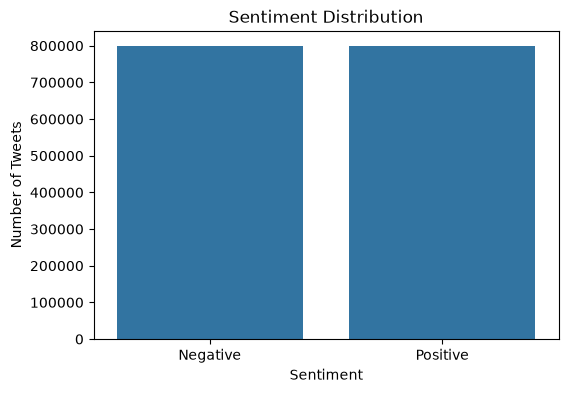

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment",
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()


# Exploratory Data Analysis (EDA)

Before building a machine learning model, it is important to understand the characteristics of the dataset.

In this section, we will:

- Analyze tweet lengths
- Visualize common words
- Generate Word Clouds
- Understand the distribution of tweet text

In [9]:
df["tweet_length"] = df["text"].apply(len)

df["tweet_length"].describe()


count    1.600000e+06
mean     7.409650e+01
std      3.645913e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      8.030000e+02
Name: tweet_length, dtype: float64

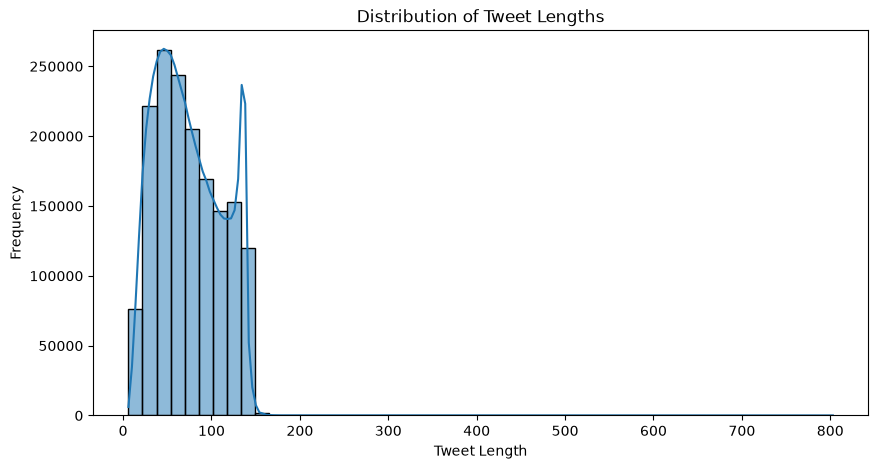

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["tweet_length"],
    bins=50,
    kde=True,
)

plt.title("Distribution of Tweet Lengths")

plt.xlabel("Tweet Length")

plt.ylabel("Frequency")

plt.show()


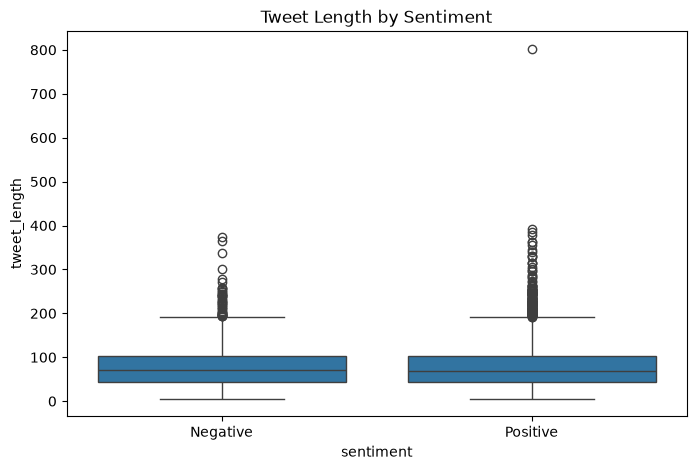

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="tweet_length",
)

plt.title("Tweet Length by Sentiment")

plt.show()


## Most Frequent Words

Understanding the most common words provides insight into the language used in social media posts before preprocessing.

In [12]:
from collections import Counter


In [13]:
all_words = " ".join(df["text"]).lower().split()

word_counts = Counter(all_words)

word_counts.most_common(20)


[('i', 746635),
 ('to', 560314),
 ('the', 518734),
 ('a', 376422),
 ('my', 312846),
 ('and', 295675),
 ('you', 237766),
 ('is', 231086),
 ('for', 214051),
 ('in', 209960),
 ('it', 191053),
 ('of', 182598),
 ('on', 161592),
 ('so', 145770),
 ('have', 143295),
 ('that', 128775),
 ('me', 128490),
 ("i'm", 127616),
 ('but', 124676),
 ('just', 124454)]

### Observation

Many of the most frequent words are stop words such as "the", "to", "and", etc.

These words carry very little sentiment information and will be removed during preprocessing.

In [14]:
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word","Count"]
)

common_words

,Word,Count
0,i,746635
1,to,560314
2,the,518734
3,a,376422
4,my,312846
5,and,295675
6,you,237766
7,is,231086
8,for,214051
9,in,209960


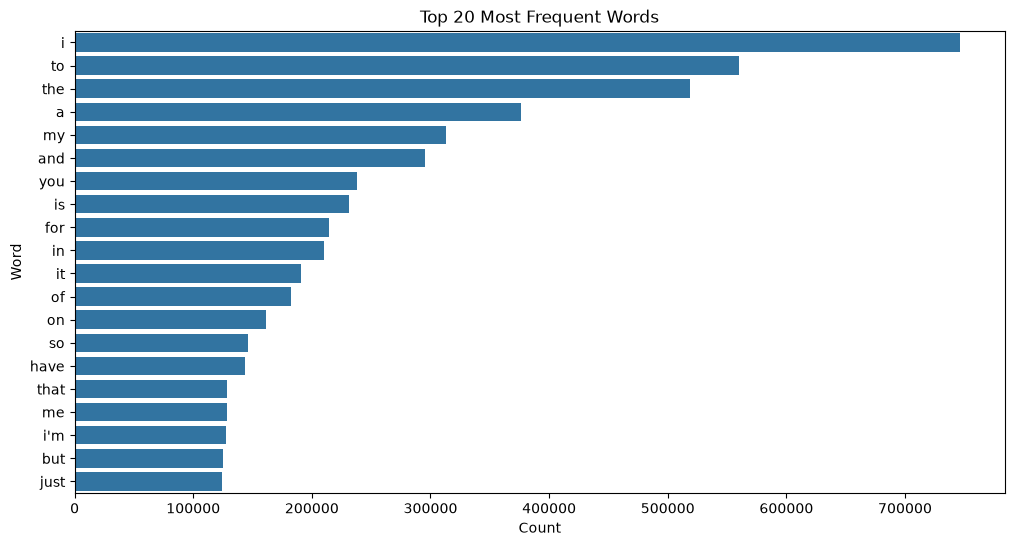

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_words,
    x="Count",
    y="Word",
)

plt.title("Top 20 Most Frequent Words")

plt.show()

## Text Preprocessing

Raw tweets contain usernames, URLs, hashtags, HTML entities, punctuation, and unnecessary whitespace.

These components do not contribute significantly to sentiment classification and are removed before feature extraction.

In [16]:
import re
import html


def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove usernames
    text = re.sub(r"@\w+", " ", text)

    # Remove # but keep the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove special characters
    text = re.sub(r"[^a-z0-9\s']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_data(df):

    processed_df = df[["target", "text"]].copy()

    # Convert labels
    processed_df["target"] = processed_df["target"].map({
        0: 0,
        4: 1
    })

    # Clean tweets
    processed_df["cleaned_text"] = processed_df["text"].apply(clean_text)

    return processed_df

In [17]:
sample = df[["text"]].head(10).copy()

sample["cleaned_text"] = sample["text"].apply(clean_text)

sample

,text,cleaned_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that's a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...
5,@Kwesidei not the whole crew,not the whole crew
6,Need a hug,need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...
8,@Tatiana_K nope they didn't have it,nope they didn't have it
9,@twittera que me muera ?,que me muera


# Feature Engineering

Machine learning models cannot process raw text directly.

The cleaned tweets are converted into numerical vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique.

The vectorizer uses:

- Unigrams and Bigrams
- Maximum Features = 50,000
- Minimum Document Frequency = 2
- Maximum Document Frequency = 95%

In [18]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

TRAIN_SAMPLE_SIZE = 800_000

TEST_SIZE = 50_000

train_pool, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["target"]
)

train_df = train_pool.sample(
    n=TRAIN_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

processed_train = preprocess_data(train_df)

processed_test = preprocess_data(test_df)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(
    processed_train["cleaned_text"]
)

X_test = vectorizer.transform(
    processed_test["cleaned_text"]
)

y_train = processed_train["target"]

y_test = processed_test["target"]

print(X_train.shape)

print(X_test.shape)

(800000, 50000)
(50000, 50000)


# Model Training

Three linear machine learning algorithms were evaluated:

- Logistic Regression
- Linear Support Vector Classifier (LinearSVC)
- SGDClassifier

The same TF-IDF features and identical train-test split were used to ensure a fair comparison.

In [20]:
model_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "LinearSVC",
        "SGDClassifier"
    ],
    "Accuracy":[
        0.8152,
        0.8141,
        0.7755
    ],
    "Macro F1":[
        0.8151,
        0.8141,
        0.7755
    ],
    "Training Time (s)":[
        8.07,
        23.16,
        2.53
    ]
})

model_results

,Model,Accuracy,Macro F1,Training Time (s)
0,Logistic Regression,0.8152,0.8151,8.07
1,LinearSVC,0.8141,0.8141,23.16
2,SGDClassifier,0.7755,0.7755,2.53


## Final Model Selection

Logistic Regression achieved the highest Accuracy and Macro F1 score among the evaluated models.

Additionally, it provides probability estimates using `predict_proba()`, making it well suited for deployment in the final sentiment analysis application.

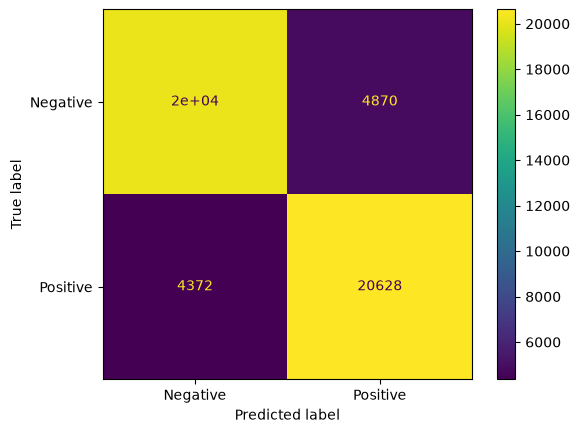

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

cm = np.array([
    [20130,4870],
    [4372,20628]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.show()

In [22]:
prediction_examples = pd.DataFrame({
    "Text":[
        "The movie was not good",
        "I thought it would be terrible but I actually loved it",
        "yeah great, exactly what I needed today"
    ],
    "Prediction":[
        "Negative",
        "Negative",
        "Positive"
    ],
    "Confidence":[
        0.9499,
        0.6701,
        0.9003
    ]
})

prediction_examples

,Text,Prediction,Confidence
0,The movie was not good,Negative,0.9499
1,I thought it would be terrible but I actually ...,Negative,0.6701
2,"yeah great, exactly what I needed today",Positive,0.9003


# Conclusion

This project successfully developed an end-to-end sentiment analysis system using the Sentiment140 dataset.

Key outcomes:

- Performed comprehensive text preprocessing.
- Converted tweet text into TF-IDF feature vectors.
- Compared three linear machine learning models.
- Selected Logistic Regression as the final model based on Accuracy, Macro F1 score, and deployment suitability.
- Saved the trained model and TF-IDF vectorizer for inference using Joblib.

The next stage of the project integrates the trained model with FastAPI, MongoDB, and a frontend interface to build a complete production-ready application.